In [24]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
data = pd.read_csv("posture_data_2.csv")



In [25]:
X_embedded = TSNE(n_components=2, learning_rate='auto',
                  init='random', perplexity=3).fit_transform(data)
X_embedded.shape

(2000, 2)

TSNE Visualisation

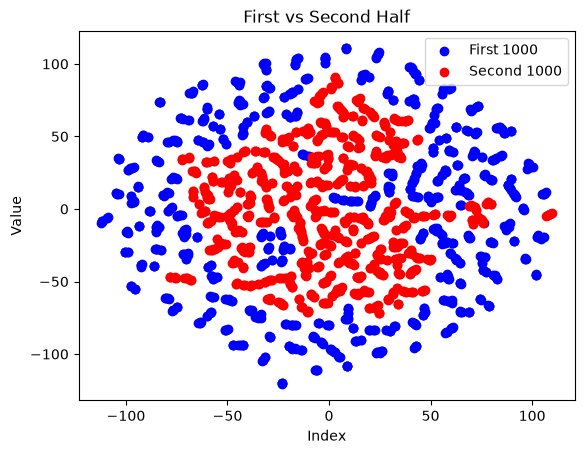

In [26]:
# Split into two parts
df1 = X_embedded[:1000]     # first 1000 rows
df2 = X_embedded[1000:2000] # next 1000 rows

# Plot
plt.scatter(df1[:, 0], df1[:, 1], color='blue', label='First 1000')
plt.scatter(df2[:, 0], df2[:, 1], color='red', label='Second 1000')

plt.legend()
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("First vs Second Half")

plt.show()


Looking at feature differences between high and low positions of the computer 

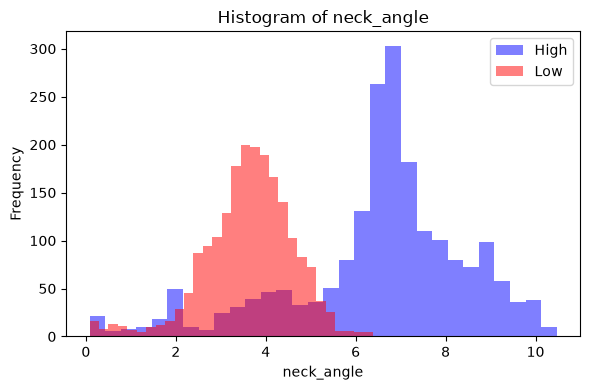

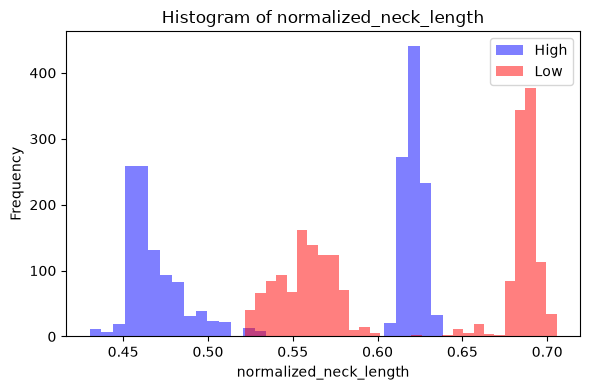

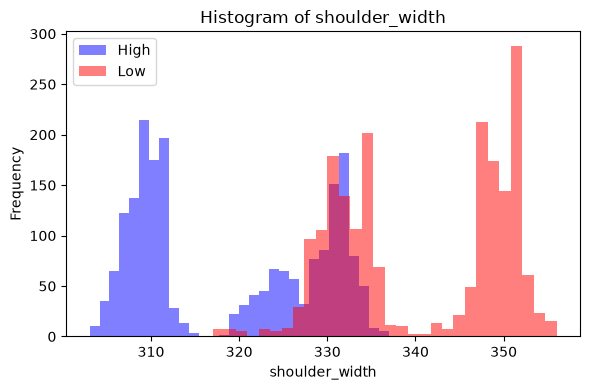

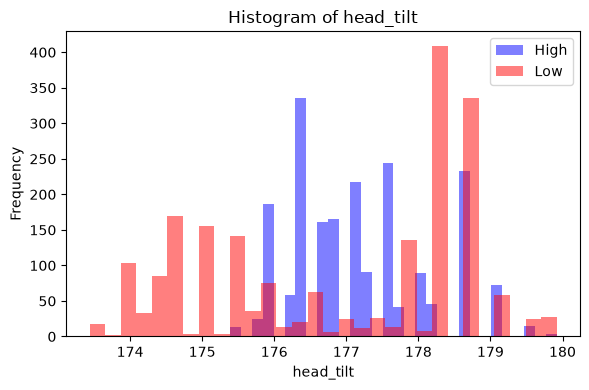

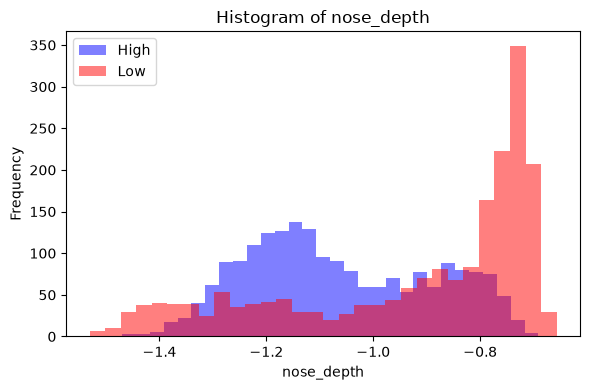

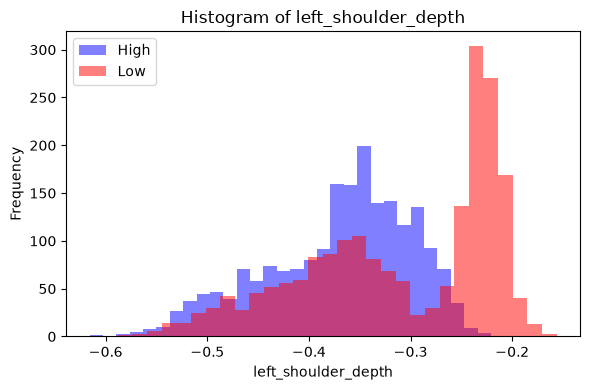

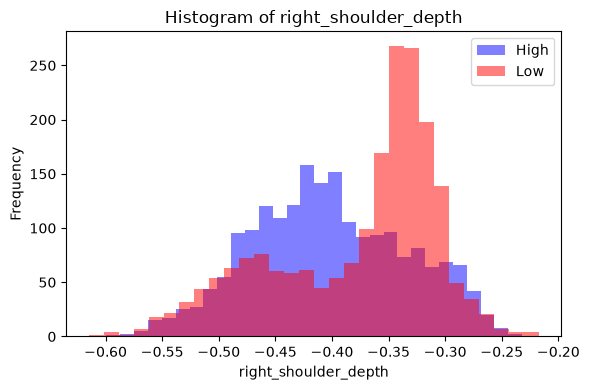

In [ ]:
# Load data
high_posture = pd.read_csv("posture_data_1.csv")
low_posture = pd.read_csv("posture_data_2.csv")

# Loop through each column
for col in high_posture.columns:
    plt.figure(figsize=(6, 4))
    
    # Plot both histograms on the same plot
    plt.hist(high_posture[col], bins=30, alpha=0.5, label='High', color='blue')
    plt.hist(low_posture[col], bins=30, alpha=0.5, label='Low', color='red')
    
    # Labels and title
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    # Legend
    plt.legend()
    
    plt.tight_layout()
    plt.show()

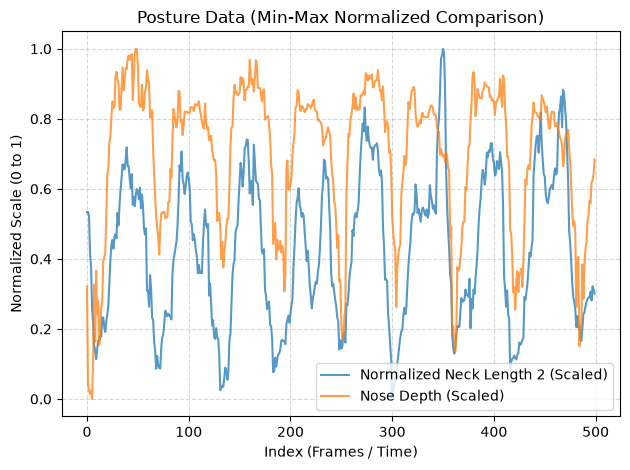

--- POSTURE DATA ANALYSIS ---
Correlation between features: 0.68

--- NORMALIZED NECK LENGTH 2 EXTREMES ---
Top 10 HIGHEST frame indices: [350, 351, 349, 348, 468, 352, 347, 469, 466, 273]
Top 10 LOWEST frame indices:  [300, 301, 131, 132, 134, 302, 133, 138, 303, 135]

--- NOSE DEPTH EXTREMES ---
Top 10 HIGHEST frame indices: [48, 49, 47, 44, 41, 43, 40, 160, 42, 166]
Top 10 LOWEST frame indices:  [5, 3, 2, 4, 1, 6, 362, 484, 12, 361]


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
data = pd.read_csv("posture_data_test.csv")

# -------------------------------------------------------------
# Min-Max Normalization (Scales values between 0 and 1)
# -------------------------------------------------------------
data["normalized_neck_length_2_scaled"] = (data["normalized_neck_length_2"] - data["normalized_neck_length_2"].min()) / (data["normalized_neck_length_2"].max() - data["normalized_neck_length_2"].min() + 1e-6)
data["nose_depth_scaled"] = (data["nose_depth"] - data["nose_depth"].min()) / (data["nose_depth"].max() - data["nose_depth"].min() + 1e-6)

# -------------------------------------------------------------
# Find Top 10 Highest and Lowest Indices
# -------------------------------------------------------------
# Using the raw columns since scaling doesn't change which index has the min/max
top_10_high_neck = data["normalized_neck_length_2"].nlargest(10).index.tolist()
top_10_low_neck = data["normalized_neck_length_2"].nsmallest(10).index.tolist()

top_10_high_nose = data["nose_depth"].nlargest(10).index.tolist()
top_10_low_nose = data["nose_depth"].nsmallest(10).index.tolist()

# -------------------------------------------------------------
# Plotting the Scaled Data
# -------------------------------------------------------------
plt.plot(data["normalized_neck_length_2_scaled"], label="Normalized Neck Length 2 (Scaled)", alpha=0.75)
plt.plot(data["nose_depth_scaled"], label="Nose Depth (Scaled)", alpha=0.75)

plt.xlabel("Index (Frames / Time)")
plt.ylabel("Normalized Scale (0 to 1)")
plt.title("Posture Data (Min-Max Normalized Comparison)")

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# Console Outputs
# -------------------------------------------------------------
print("--- POSTURE DATA ANALYSIS ---")
correlation = data["normalized_neck_length_2"].corr(data["nose_depth"])
print(f"Correlation between features: {correlation:.2f}\n")

print("--- NORMALIZED NECK LENGTH 2 EXTREMES ---")
print(f"Top 10 HIGHEST frame indices: {top_10_high_neck}")
print(f"Top 10 LOWEST frame indices:  {top_10_low_neck}\n")

print("--- NOSE DEPTH EXTREMES ---")
print(f"Top 10 HIGHEST frame indices: {top_10_high_nose}")
print(f"Top 10 LOWEST frame indices:  {top_10_low_nose}")

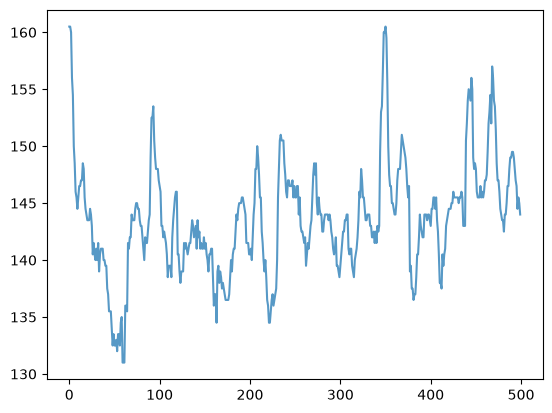

In [10]:
plt.plot(data["normalized_neck_length"], label="Nose Depth", alpha=0.75)